In [27]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [28]:
load_dotenv()

True

In [29]:
llm= ChatGroq(model="llama-3.3-70b-versatile")

In [30]:
class SubState(TypedDict):
    input_text: str
    translate_text: str

In [31]:
subgraph_llm= ChatGroq(model="llama-3.3-70b-versatile")

In [32]:
def translate_text(state:SubState):
        prompt=f""""
            translate the folowing text into hindi.
            keep it natural and real
     
                 text:
                 {state['input_text']} 
                    """.strip()
        translate_text=subgraph_llm.invoke(prompt).content

        return{'translate_text':translate_text}

In [33]:
subgraph_builder=StateGraph(SubState)

subgraph_builder.add_node('translate_text',translate_text)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)

subgraph= subgraph_builder.compile()

In [34]:
class ParentState(TypedDict):
    question:str
    answer_eng:str
    answer_hin:str

In [35]:
parent_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [36]:
def generate_answer(state: ParentState):
    answer=parent_llm.invoke(f"You are a helful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng':answer}

In [37]:
def translate_answer(state:ParentState):
    result = subgraph.invoke({
    "input_text": state["answer_eng"]
})

    return{'answer_hin':result['translate_text']}

In [38]:
parent_builder=StateGraph(ParentState)

parent_builder.add_node('answer',generate_answer)
parent_builder.add_node('translate_text',translate_answer)

parent_builder.add_edge(START,'answer')
parent_builder.add_edge('answer','translate_text')
parent_builder.add_edge('translate_text',END)

In [39]:
graph=parent_builder.compile()

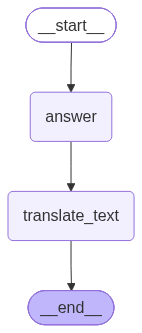

In [40]:
graph

In [41]:
graph.invoke({'question':'what is photosynthesis?'})

{'question': 'what is photosynthesis?',
 'answer_eng': '**Photosynthesis** is the process by which plants, algae, and some bacteria convert light energy from the sun into chemical energy in the form of glucose (a type of sugar). This process occurs in specialized organelles called chloroplasts, which contain the pigment chlorophyll.\n\n**The basic equation for photosynthesis is:**\n\n6 CO2 (carbon dioxide) + 6 H2O (water) + light energy → C6H12O6 (glucose) + 6 O2 (oxygen)\n\n**In simple terms, photosynthesis:**\n\n1. Absorbs carbon dioxide from the air\n2. Absorbs water from the soil\n3. Uses light energy from the sun\n4. Produces glucose (energy-rich sugar) and oxygen\n\n**Photosynthesis is essential for life on Earth** as it provides:\n\n* Energy and organic compounds for plants to grow\n* Oxygen for animals and humans to breathe\n* Food for herbivores, which in turn support carnivores and the entire food chain.',
 'answer_hin': '**प्रकाश संश्लेषण** पौधों, शैवाल और कुछ जीवाणुओं द्वार